Groundwater Level Prediction using Machine Learning




Importing all library

In [42]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Models
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Evaluation
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [43]:

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

Load datatset


In [44]:
df = pd.read_csv("D:/NIH_roorkee/GWL_Monsoon.csv")

print(df.head())
print(df.shape)

     Station  Year  Latitude  Longitude    ET_Mon   RH_Mon  Wind_Mon  \
0  Station-1  1992   25.0208    83.0403  352.1525  66.8711    4.8606   
1  Station-2  1992   24.9272    83.0444  352.1525  66.8711    4.8606   
2  Station-3  1992   24.8833    82.7917  352.1525  66.8711    4.8606   
3  Station-4  1992   25.1528    82.3917  352.1525  66.8711    4.8606   
4  Station-5  1992   25.1583    82.4833  352.1525  66.8711    4.8606   

   Rainfall_Mon  NDVI_Mon  NDBI_Mon  NDMI_Mon  NDWI_Mon  Temp_Min_Mon  \
0      764.2461    0.1565    -0.017     0.017   -0.1751        53.957   
1      764.2461    0.1565    -0.017     0.017   -0.1751        53.957   
2      764.2461    0.1565    -0.017     0.017   -0.1751        53.957   
3      764.2461    0.1565    -0.017     0.017   -0.1751        53.957   
4      764.2461    0.1565    -0.017     0.017   -0.1751        53.957   

   Temp_Max_Mon  SM_10cm_Mon  SM_40cm_Mon  SM_100cm_Mon  GWL_Mon  
0        68.151      27.6711      25.8687       21.4581     1

In [45]:
print(df.info())

print(df.describe())

print(df.isnull().sum())
df = df.sort_values(["Station", "Year"])


<class 'pandas.DataFrame'>
RangeIndex: 279 entries, 0 to 278
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Station       279 non-null    str    
 1   Year          279 non-null    int64  
 2   Latitude      279 non-null    float64
 3   Longitude     279 non-null    float64
 4   ET_Mon        279 non-null    float64
 5   RH_Mon        279 non-null    float64
 6   Wind_Mon      279 non-null    float64
 7   Rainfall_Mon  279 non-null    float64
 8   NDVI_Mon      279 non-null    float64
 9   NDBI_Mon      279 non-null    float64
 10  NDMI_Mon      279 non-null    float64
 11  NDWI_Mon      279 non-null    float64
 12  Temp_Min_Mon  279 non-null    float64
 13  Temp_Max_Mon  279 non-null    float64
 14  SM_10cm_Mon   279 non-null    float64
 15  SM_40cm_Mon   279 non-null    float64
 16  SM_100cm_Mon  279 non-null    float64
 17  GWL_Mon       279 non-null    float64
dtypes: float64(16), int64(1), str(1)
memory u

In [46]:
df.columns


Index(['Station', 'Year', 'Latitude', 'Longitude', 'ET_Mon', 'RH_Mon',
       'Wind_Mon', 'Rainfall_Mon', 'NDVI_Mon', 'NDBI_Mon', 'NDMI_Mon',
       'NDWI_Mon', 'Temp_Min_Mon', 'Temp_Max_Mon', 'SM_10cm_Mon',
       'SM_40cm_Mon', 'SM_100cm_Mon', 'GWL_Mon'],
      dtype='str')

In [47]:
df.fillna(df.median(numeric_only=True), inplace=True)

,Station,Year,Latitude,Longitude,ET_Mon,RH_Mon,Wind_Mon,Rainfall_Mon,NDVI_Mon,NDBI_Mon,NDMI_Mon,NDWI_Mon,Temp_Min_Mon,Temp_Max_Mon,SM_10cm_Mon,SM_40cm_Mon,SM_100cm_Mon,GWL_Mon
0,Station-1,1992,25.0208,83.0403,352.1525,66.8711,4.8606,764.2461,0.1565,-0.0170,0.0170,-0.1751,53.957,68.151,27.6711,25.8687,21.4581,1.57
9,Station-1,1993,25.0208,83.0403,393.2202,72.7488,5.1221,923.2823,0.0400,0.0304,-0.0304,-0.0683,54.473,66.563,28.8971,27.2910,20.0611,1.63
18,Station-1,1994,25.0208,83.0403,548.6927,74.7752,4.8331,1239.7806,0.1450,-0.0166,0.0166,-0.1655,53.469,65.855,35.4562,34.7591,32.0289,1.21
27,Station-1,1995,25.0208,83.0403,483.3867,72.3767,4.9115,1058.7614,0.0000,0.0000,0.0000,0.0000,54.225,67.289,33.3740,30.6864,27.7725,0.91
36,Station-1,1996,25.0208,83.0403,466.5666,76.1953,4.3189,1263.2860,0.0000,0.0000,0.0000,0.0000,54.446,65.837,34.6193,33.6119,31.1133,1.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242,Station-9,2018,25.0208,82.3639,481.4804,72.9258,5.1656,999.2212,0.1754,-0.0230,0.0230,-0.2002,54.497,66.182,33.7981,31.9714,28.9114,1.37
251,Station-9,2019,25.0208,82.3639,474.5008,74.2379,4.8447,1272.4750,0.0365,0.0284,-0.0284,-0.0643,54.790,66.702,33.8973,32.4489,31.3920,2.11
260,Station-9,2020,25.0208,82.3639,553.9848,81.0492,4.3928,1122.5853,0.0000,0.0000,0.0000,0.0000,53.852,64.417,38.7711,38.5508,37.5394,0.00
269,Station-9,2021,25.0208,82.3639,558.4222,79.5878,4.7309,1136.5347,0.1570,-0.0619,0.0619,-0.1487,54.463,64.642,37.9813,37.4331,36.3167,1.79


Lag feature are introduced


In [48]:
df.drop_duplicates(inplace=True)

df['GWL_lag_1'] = df['GWL_Mon'].shift(1)
df['GWL_lag_2'] = df['GWL_Mon'].shift(2)

df['Rain_lag_1'] = df['Rainfall_Mon'].shift(1)
df['Rain_lag_2'] = df['Rainfall_Mon'].shift(2)

df['Rain_roll3'] = df['Rainfall_Mon'].rolling(3).mean()
df["GWL_lag_1"] = df.groupby("Station")["GWL_Mon"].shift(1)
df["GWL_lag_2"] = df.groupby("Station")["GWL_Mon"].shift(2)
df.dropna(inplace=True)

 DROP NON-PREDICTIVE COLUMNS

In [102]:

#    Year, Latitude, Longitude — identifiers / spatial metadata, not features
#    Also drop any ID-like or date-like columns that leak or are irrelevant
drop_meta = [c for c in [ 'year','Latitude', 'Longitude', 'Month','SM_10cm_Mon', 'SM_40cm_Mon',
                          'Station_No', 'Sl_No', 'ID', 'Date','Rainfall_Mon','Temp_Min_Mon', 'Temp_Max_Mon','NDWI_Mon', 'NDBI_Mon'] if c in df.columns]
df.drop(columns=drop_meta, inplace=True)
print(f"\nDropped meta/identifier columns: {drop_meta}")



Dropped meta/identifier columns: []


In [103]:
temp_max = 'Temp_Max_Mon'
temp_min = 'Temp_Min_Mon'
temp_mean = 'Temp_Mean_Mon'   

temp_available = [c for c in [temp_max, temp_min, temp_mean] if c in df.columns]

if temp_max in df.columns and temp_min in df.columns:
    df['Temp_Avg'] = (df[temp_max] + df[temp_min]) / 2
    print(f"\nCreated Temp_Avg = ({temp_max} + {temp_min}) / 2")
elif temp_mean in df.columns:
    df['Temp_Avg'] = df[temp_mean]
    print(f"\nUsed {temp_mean} as Temp_Avg directly.")
else:
    print("\nNo temperature columns found; skipping Temp_Avg creation.")


No temperature columns found; skipping Temp_Avg creation.


In [ ]:
# Drop all original / redundant temperature columns
redundant_temp = [c for c in [temp_mean,
                               'Temp_Range',      
                               'LST_Day_Mon',        
                               'LST_Night_Mon']      
                  if c in df.columns]
df.drop(columns=redundant_temp, inplace=True)
print(f"Dropped redundant temperature columns: {redundant_temp}")

Dropped redundant temperature columns: []


ONE-HOT ENCODE remaining categorical columns (non-station) 

In [ ]:

cat_features = df.select_dtypes(include=["object"]).columns.tolist()
if cat_features:
    df = pd.get_dummies(df, columns=cat_features, drop_first=True)
    print(f"One-hot encoded: {cat_features}")

print("\nColumns after encoding:", df.columns.tolist())
print("Shape after encoding  :", df.shape)


Columns after encoding: ['Year', 'ET_Mon', 'RH_Mon', 'Wind_Mon', 'NDVI_Mon', 'NDMI_Mon', 'SM_100cm_Mon', 'GWL_Mon', 'GWL_lag_1', 'GWL_lag_2', 'Rain_lag_1', 'Rain_lag_2', 'Rain_roll3', 'Temp_Avg']
Shape after encoding  : (261, 14)


In [ ]:
station_cols = [c for c in df.columns
                if c == 'Station' or c.lower().startswith('station_')]
df.drop(columns=station_cols, inplace=True)
print(f"\nDropped all station columns: {station_cols}")




Dropped all station columns: []
Dropped spectral index columns: []


In [80]:
target = "GWL_Mon"
X = df.drop(columns=[target])

y = df[target]

Correleation Matrix


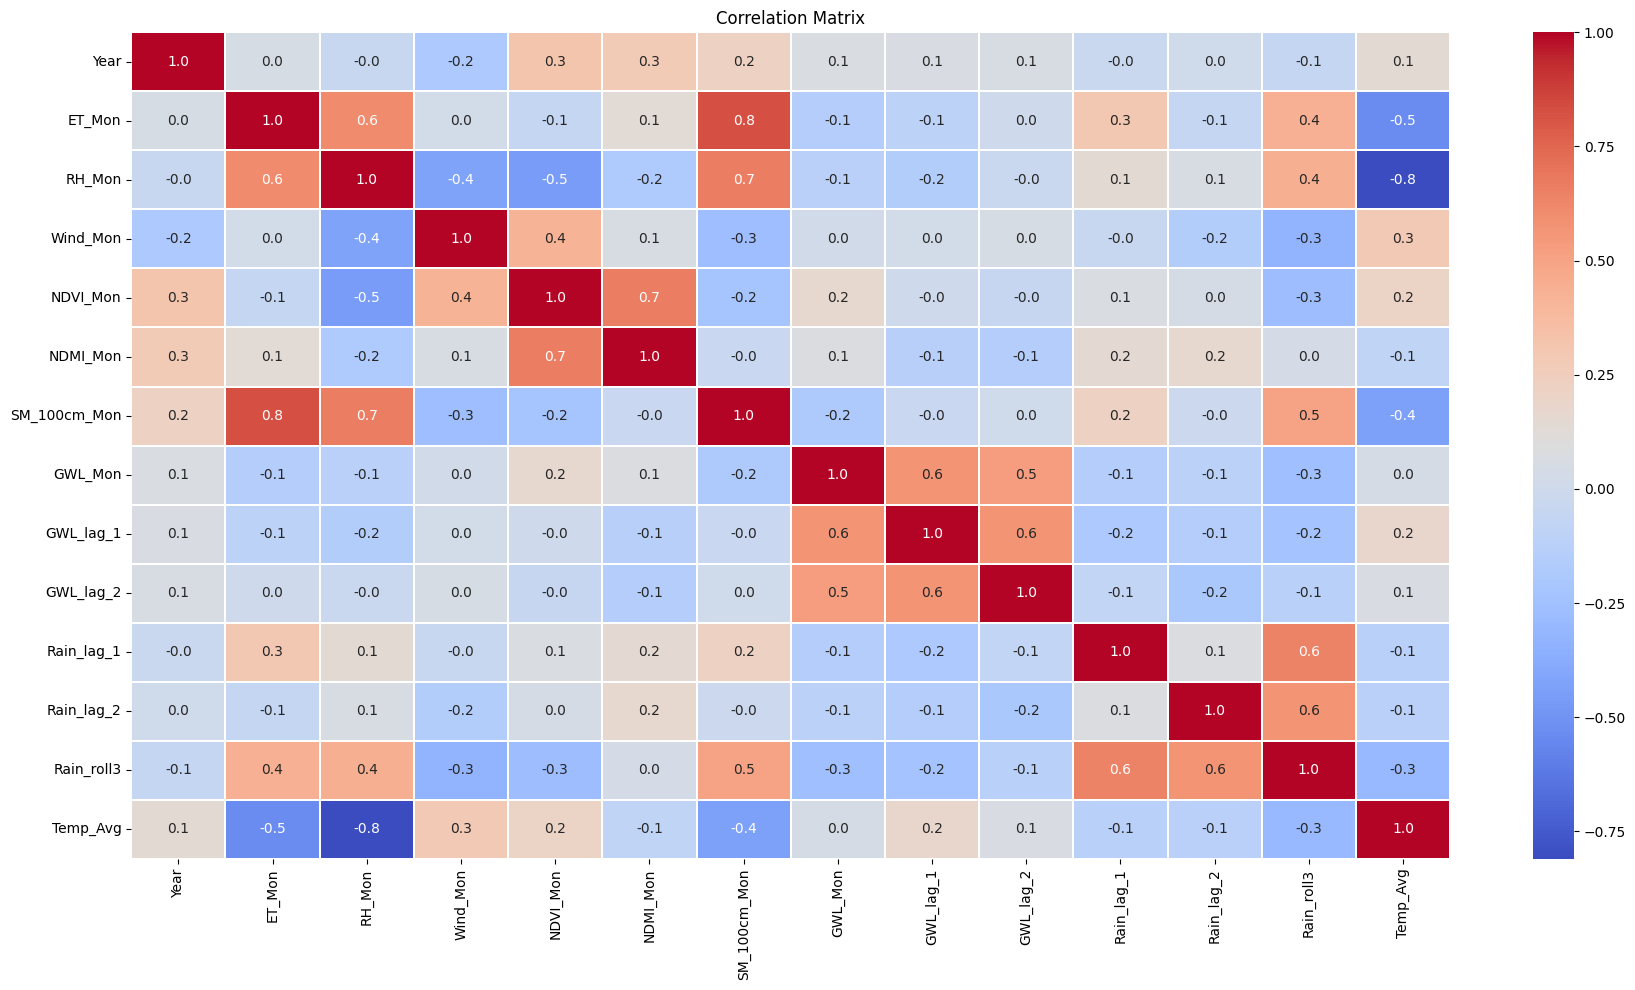

GWL_Mon       1.000000
GWL_lag_1     0.570791
GWL_lag_2     0.532446
Rain_roll3   -0.260440
Name: GWL_Mon, dtype: float64


In [81]:
plt.figure(figsize=(18, 10))
sns.heatmap(df.corr(), annot=True, fmt=".1f", cmap='coolwarm', linewidths=0.3)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=120)
plt.show()
corr = df.corr()

high_corr = corr[
    abs(corr['GWL_Mon']) > 0.2
]

print(high_corr['GWL_Mon'])

In [57]:
# Sort by time first
df = df.sort_values("Year")

# Train = past years
train_df = df[df["Year"] <= 2020]

# Test = future years
test_df = df[df["Year"] > 2020]

X_train = train_df.drop(columns=["GWL_Mon"])
y_train = train_df["GWL_Mon"]

X_test = test_df.drop(columns=["GWL_Mon"])
y_test = test_df["GWL_Mon"]

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (243, 16)
Test shape : (18, 16)


Random forest model

In [83]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
print("Train R2 =", rf.score(X_train, y_train))
print("Test R2  =", rf.score(X_test, y_test))

Train R2 = 0.9416967180403104
Test R2  = 0.684672867149903


XGBoost model

In [ ]:

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.01,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
print("Train R2 =", xgb.score(X_train, y_train))
print("Test R2  =", xgb.score(X_test, y_test))

Train R2 = 0.8283325419029577
Test R2  = 0.6630857033599631


CatBoost Model

In [86]:
cat = CatBoostRegressor(
    iterations=300,
    learning_rate=0.6,
    depth=3,
    verbose=0
)

cat.fit(X_train, y_train)

cat_pred = cat.predict(X_test)
print("Train R2 =", cat.score(X_train, y_train))
print("Test R2  =", cat.score(X_test, y_test))

Train R2 = 0.9980081987570587
Test R2  = 0.8008297950658672


In [87]:
def evaluate_model(y_true, y_pred, model_name):

    r2 = r2_score(y_true, y_pred)

    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    print("\n", model_name)
    print("R2 Score :", r2)
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE :", rmse)

    return [model_name,r2,mae,mse,rmse]

In [88]:
results=[]

results.append(
    evaluate_model(y_test,rf_pred,"Random Forest")
)

results.append(
    evaluate_model(y_test,xgb_pred,"XGBoost")
)

results.append(
    evaluate_model(y_test,cat_pred,"CatBoost")
)


 Random Forest
R2 Score : 0.684672867149903
MAE : 1.841405976234014
MSE : 5.186883063928569
RMSE : 2.277472955696416

 XGBoost
R2 Score : 0.6630857033599631
MAE : 1.7953720140457152
MSE : 5.541974911712948
RMSE : 2.3541399515986616

 CatBoost
R2 Score : 0.8008297950658672
MAE : 1.4530864726689865
MSE : 3.276193055366241
RMSE : 1.8100257057197395


In [89]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "R2",
        "MAE",
        "MSE",
        "RMSE"
    ]
)

print(results_df)

print(
    results_df.sort_values(
        by="R2",
        ascending=False
    )
)

           Model        R2       MAE       MSE      RMSE
0  Random Forest  0.684673  1.841406  5.186883  2.277473
1        XGBoost  0.663086  1.795372  5.541975  2.354140
2       CatBoost  0.800830  1.453086  3.276193  1.810026
           Model        R2       MAE       MSE      RMSE
2       CatBoost  0.800830  1.453086  3.276193  1.810026
0  Random Forest  0.684673  1.841406  5.186883  2.277473
1        XGBoost  0.663086  1.795372  5.541975  2.354140


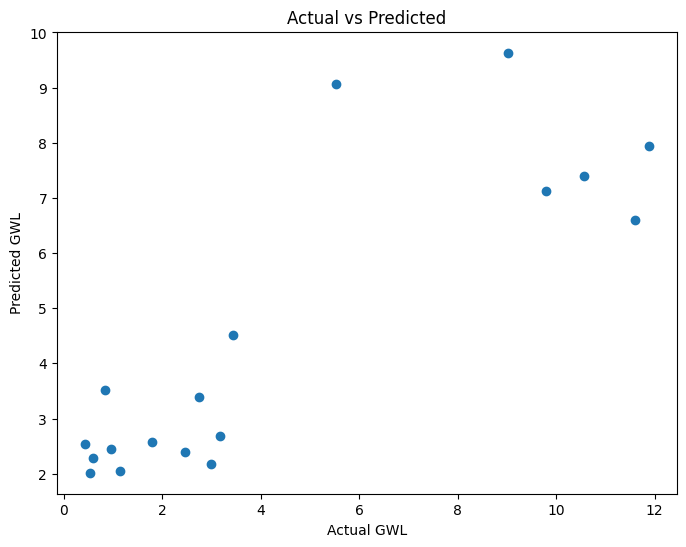

In [90]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    
    rf_pred
)

plt.xlabel("Actual GWL")

plt.ylabel("Predicted GWL")

plt.title("Actual vs Predicted")

plt.show()

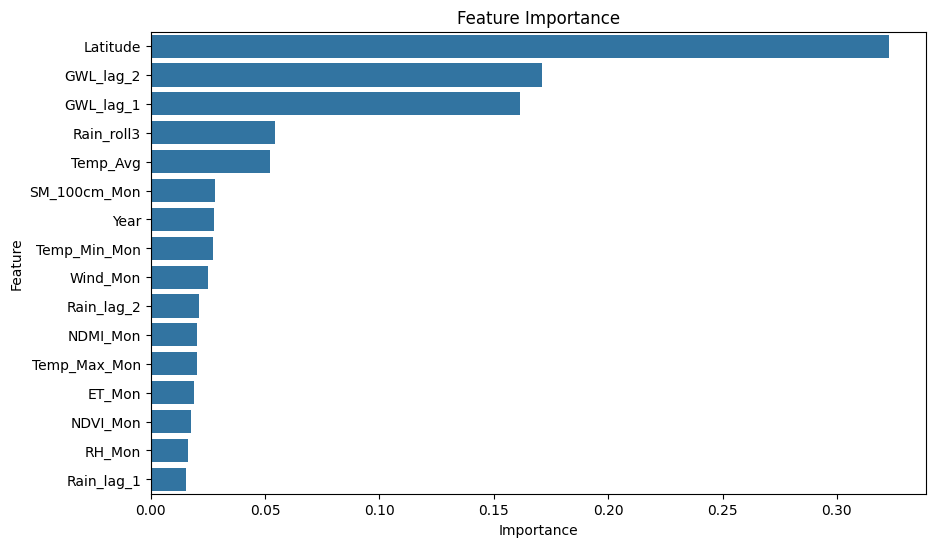

In [101]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title(
    "Feature Importance"
)

plt.show()

In [93]:
import joblib

joblib.dump(
    rf,
    "Groundwater_RF_Model.pkl"
)

['Groundwater_RF_Model.pkl']

In [94]:
model = joblib.load(
    "Groundwater_RF_Model.pkl"
)

In [95]:
current_gwl = model.predict(X_test)

print(current_gwl[:5])

[9.63158631 2.01748403 3.39391168 2.27893029 7.39824583]


In [96]:
def digital_twin_simulation(sample,
                            rainfall_change=0,
                            temp_change=0,
                            sm_change=0):

    scenario = sample.copy()

    scenario['Rain_lag_1'] *= (1 + rainfall_change/100)

    scenario['Temp_Avg'] += temp_change
    scenario['SM_100cm_Mon'] *= (1 + sm_change/100)

    return model.predict(scenario)

In [97]:
#senerio A
sample = X_test.iloc[[0]]


In [98]:
#senerio B
pred = digital_twin_simulation(
    sample,
    rainfall_change=20
)

print(pred)

[9.50561964]


In [99]:
#senerio c
pred = digital_twin_simulation(
    sample,
    rainfall_change=-30,
    sm_change=-20
)

print(pred)

[9.30492853]


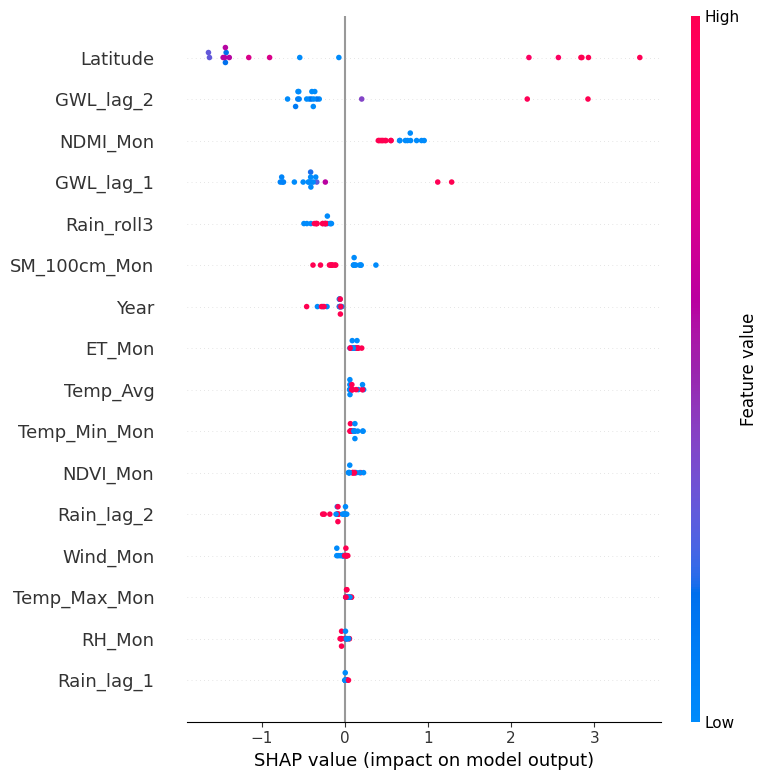

In [100]:
#shap explabel

import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [ ]:
#WRITTEN BY Aman Kumar Ranjan, NIH Roorkee